# 04 — Gradient Boosting Benchmark Model

This notebook implements a **gradient boosting classifier** as a benchmark model for heart disease prediction. It complements the logistic regression analysis (notebook 03) by testing whether a more flexible, non-linear model achieves meaningfully better performance.

We use the **full feature set including `source_code`** (hospital origin) as the single model variant, with fixed hyperparameters (no grid search). The dataset is small (920 rows) and the goal is a fair comparison with logistic regression — extensive tuning would risk overfitting and is not justified at this scale.

## Focus: Minimising False Negatives

Since this is a **medical screening model**, the worst outcome is a **false negative** — predicting "no disease" when a patient actually has heart disease. We therefore analyse multiple classification thresholds to find a point that minimises FN, accepting more false positives (unnecessary referrals) in exchange for catching nearly all true cases.

## Hyperparameters (fixed)

| Parameter | Value | Rationale |
|-----------|-------|-----------|
| `n_estimators` | 100 | Sufficient for a small dataset |
| `learning_rate` | 0.05 | Conservative step size, reduces overfitting |
| `max_depth` | 2 | Shallow trees (stumps+1) — prevents overfitting |
| `min_samples_leaf` | 5 | Prevents overly specific leaf nodes |
| `subsample` | 0.8 | Each tree sees a random 80 % of training rows → adds stochasticity, reduces overfitting (stochastic gradient boosting) |

In [1]:
import sys, os, warnings
sys.path.append(os.path.abspath(".."))
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import shap

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_curve, auc,
    precision_score, recall_score, f1_score, accuracy_score,
    roc_auc_score,
)

from src.utils import (
    RANDOM_STATE, load_processed_data, get_feature_target_split,
    get_column_groups, build_preprocessor,
    plot_roc_curve, classification_report_df,
)

FIGURES = "../results/figures"
TABLES  = "../results/tables"
MODELS  = "../results/models"

plt.rcParams.update({"figure.dpi": 150, "savefig.dpi": 150})
pd.set_option("display.max_columns", 20)
print("Setup complete.")


Setup complete.


## 1 — Data Loading & Preparation

All 12 clinical features plus `source_code` (hospital origin) are included. Before modelling, we inspect the disease prevalence per source to understand potential biases.

In [2]:
df = load_processed_data()
print(f"Shape: {df.shape}")
print(f"NaN values: {df.isna().sum().sum()}")

print(f"\nTarget distribution:")
print(df["num"].value_counts().sort_index())

# Disease prevalence by source
source_map = {1: "Cleveland", 2: "Hungarian", 3: "Long Beach VA", 4: "Switzerland"}
source_disease = df.groupby("source_code")["num"].value_counts().unstack(fill_value=0)
source_disease.index = source_disease.index.map(source_map)
source_disease.columns = ["No Disease", "Disease"]
source_disease["Total"] = source_disease.sum(axis=1)
source_disease["Disease %"] = (source_disease["Disease"] / source_disease["Total"] * 100).round(1)
print("\nDisease prevalence by source hospital:")
print(source_disease)

# Sex distribution
sex_counts = df["sex"].value_counts()
print(f"\nSex distribution: Male = {int(sex_counts.get(1, 0))} ({sex_counts.get(1, 0)/len(df)*100:.1f}%), "
      f"Female = {int(sex_counts.get(0, 0))} ({sex_counts.get(0, 0)/len(df)*100:.1f}%)")


Shape: (920, 14)
NaN values: 0

Target distribution:
num
0    411
1    509
Name: count, dtype: int64

Disease prevalence by source hospital:
               No Disease  Disease  Total  Disease %
source_code                                         
Cleveland             164      139    303       45.9
Hungarian             188      106    294       36.1
Long Beach VA          51      149    200       74.5
Switzerland             8      115    123       93.5

Sex distribution: Male = 726 (78.9%), Female = 194 (21.1%)


In [3]:
# Single variant: full_source (all clinical features + hospital origin)
X, y = get_feature_target_split(df, drop_source=False, drop_high_missing=False)
groups = get_column_groups(X)
print(f"Features: {X.shape[1]}  "
      f"(cont={len(groups['continuous'])}, bin={len(groups['binary'])}, multi={len(groups['multiclass'])})")
print(f"Columns: {list(X.columns)}")


Features: 13  (cont=5, bin=3, multi=5)
Columns: ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'thal', 'source_code']


In [4]:
# Stratified 80/20 split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)
print(f"Train: {len(X_train)} samples  (pos={y_train.sum()}, neg={len(y_train)-y_train.sum()})")
print(f"Test:  {len(X_test)} samples  (pos={y_test.sum()}, neg={len(y_test)-y_test.sum()})")


Train: 736 samples  (pos=407, neg=329)
Test:  184 samples  (pos=102, neg=82)


## 2 — Model Training & Cross-Validation

We build a single pipeline (ColumnTransformer → GradientBoostingClassifier) with fixed hyperparameters. No grid search is performed — the dataset is too small to benefit meaningfully from tuning, and the goal is a fair benchmark comparison against logistic regression.

`subsample = 0.8` means each boosting iteration trains on a random 80 % of the training rows (without replacement). This is called *stochastic gradient boosting*. The randomness decorrelates successive trees and acts as implicit regularisation, similar to bagging in random forests. On small datasets like ours, it consistently reduces overfitting compared to using the full sample (`subsample = 1.0`).

Important distinction — subsample vs. cross-validation: These are two separate mechanisms operating at different levels.
- `subsample` works *inside* the training process: each of the 100 boosting rounds randomly draws 80 % of the training data to build its tree. It is a regularisation technique — it never produces an evaluation score.
- Cross-validation (5-fold CV) works *outside* the model: it splits the training set into 5 folds, trains 5 independent models, and evaluates each on its held-out fold to estimate generalisation performance. It produces the `CV ROC-AUC` score we report below.

In short: CV tells us *how good* the model is; subsample helps *make* the model better.

In [5]:
# Fixed hyperparameters
GBC_PARAMS = dict(
    n_estimators=100,
    learning_rate=0.05,
    max_depth=2,
    min_samples_leaf=5,
    subsample=0.8,
    random_state=RANDOM_STATE,
)

# Build pipeline
preprocessor = build_preprocessor(groups)
pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", GradientBoostingClassifier(**GBC_PARAMS)),
])

# 5-fold stratified cross-validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_scores = cross_val_score(pipe, X_train, y_train, cv=cv, scoring="roc_auc")
print(f"CV ROC-AUC: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
print(f"Per fold:   {np.round(cv_scores, 4)}")

# Fit on full training set
pipe.fit(X_train, y_train)

# Predict probabilities on test set
y_prob = pipe.predict_proba(X_test)[:, 1]
y_pred_default = (y_prob >= 0.5).astype(int)

test_auc = roc_auc_score(y_test, y_prob)
print(f"\nTest ROC-AUC:  {test_auc:.4f}")
print(f"\nClassification report (default threshold = 0.5):")
print(classification_report(y_test, y_pred_default, target_names=["No Disease", "Disease"]))


CV ROC-AUC: 0.8903 ± 0.0254
Per fold:   [0.8676 0.8608 0.9276 0.8846 0.9109]

Test ROC-AUC:  0.9176

Classification report (default threshold = 0.5):
              precision    recall  f1-score   support

  No Disease       0.85      0.77      0.81        82
     Disease       0.83      0.89      0.86       102

    accuracy                           0.84       184
   macro avg       0.84      0.83      0.83       184
weighted avg       0.84      0.84      0.84       184



## 3 — Threshold Optimisation: Minimising False Negatives

The default classification threshold of 0.5 is probably not optimal for a medical screening tool. A false negative (FN) means the model says "no disease" but the patient actually has heart disease — this is the most dangerous outcome.

Our use case: this model could serve as a first-pass screening tool. If the model predicts disease, the patient is referred to a cardiologist for a thorough examination. Therefore:
- False positives are acceptable: they just trigger an extra check-up
- False negatives are unacceptable: a sick patient walks away untreated

We examine the ROC curve to identify thresholds that maximise recall (sensitivity) while keeping specificity at a reasonable level.

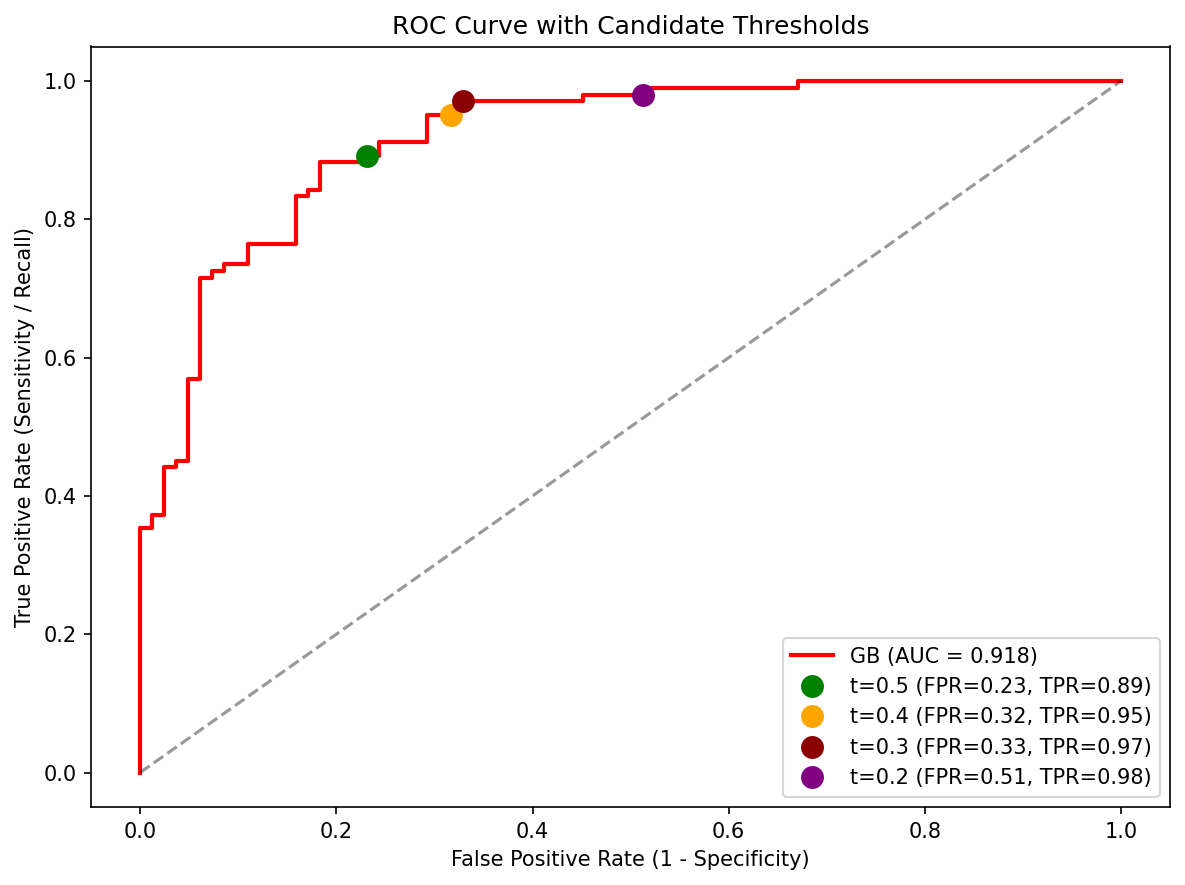

In [6]:
# ROC Curve with candidate thresholds marked
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc_val = auc(fpr, tpr)

# Candidate thresholds to compare
candidate_thresholds = [0.5, 0.4, 0.3, 0.2]

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(fpr, tpr, "r-", lw=2, label=f"GB (AUC = {roc_auc_val:.3f})")
ax.plot([0, 1], [0, 1], "k--", alpha=0.4)

# Mark candidate thresholds on the ROC curve
colors = ["green", "orange", "darkred", "purple"]
for thresh, color in zip(candidate_thresholds, colors):
    # Find the closest threshold in the ROC curve
    idx = np.argmin(np.abs(thresholds - thresh))
    ax.plot(fpr[idx], tpr[idx], "o", color=color, markersize=10,
            label=f"t={thresh:.1f} (FPR={fpr[idx]:.2f}, TPR={tpr[idx]:.2f})")

ax.set_xlabel("False Positive Rate (1 - Specificity)")
ax.set_ylabel("True Positive Rate (Sensitivity / Recall)")
ax.set_title("ROC Curve with Candidate Thresholds")
ax.legend(loc="lower right")
fig.savefig(f"{FIGURES}/gb_roc_curve.png", dpi=150, bbox_inches="tight")
plt.tight_layout()
plt.show()

## 4 — Confusion Matrices at Different Thresholds

We compare several thresholds to understand the trade-off between false negatives and false positives. For each threshold, we show the confusion matrix and compute key metrics.

Reminder: In our confusion matrix, the critical cell is the False Negative (FN) — actual Disease predicted as No Disease.

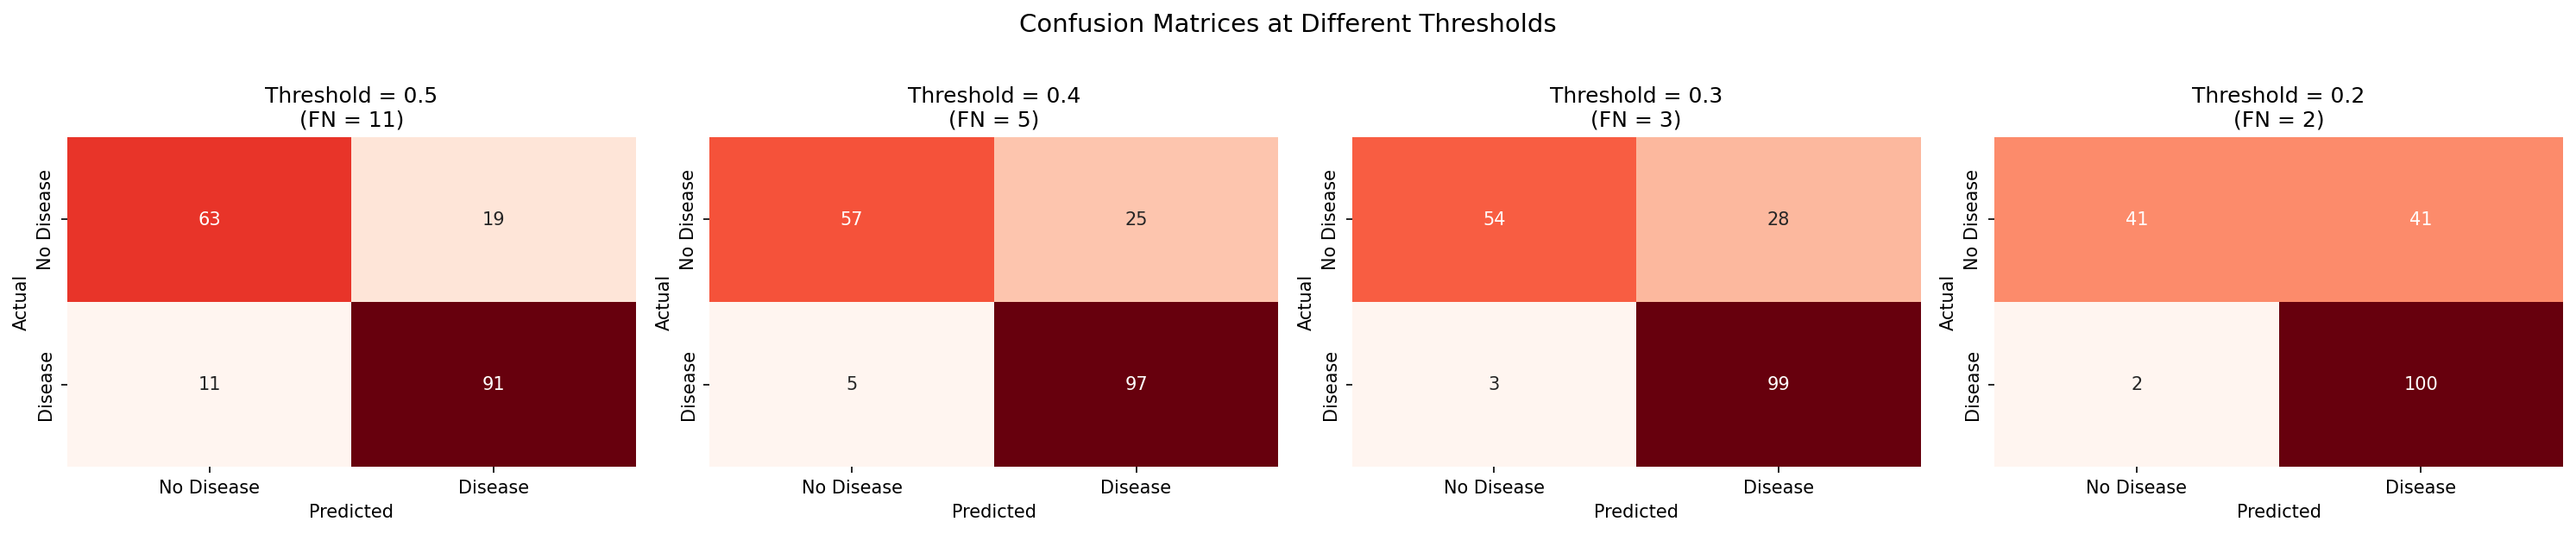

In [7]:
# Confusion matrices side by side for all candidate thresholds
fig, axes = plt.subplots(1, len(candidate_thresholds), figsize=(5 * len(candidate_thresholds), 4))

for i, thresh in enumerate(candidate_thresholds):
    y_pred_t = (y_prob >= thresh).astype(int)
    cm = confusion_matrix(y_test, y_pred_t)
    
    sns.heatmap(cm, annot=True, fmt="d", cmap="Reds",
                xticklabels=["No Disease", "Disease"],
                yticklabels=["No Disease", "Disease"],
                ax=axes[i], cbar=False)
    axes[i].set_xlabel("Predicted")
    axes[i].set_ylabel("Actual")
    
    fn = cm[1, 0]  # actual=Disease, predicted=No Disease
    axes[i].set_title(f"Threshold = {thresh}\n(FN = {fn})")

fig.suptitle("Confusion Matrices at Different Thresholds", fontsize=14, y=1.02)
fig.savefig(f"{FIGURES}/gb_confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.tight_layout()
plt.show()

In [8]:
# Detailed metrics comparison across thresholds
rows = []
for thresh in candidate_thresholds:
    y_pred_t = (y_prob >= thresh).astype(int)
    cm = confusion_matrix(y_test, y_pred_t)
    tn, fp, fn, tp = cm.ravel()
    
    rows.append({
        "Threshold": thresh,
        "TP": tp, "FP": fp, "FN": fn, "TN": tn,
        "Accuracy": accuracy_score(y_test, y_pred_t),
        "Precision": precision_score(y_test, y_pred_t, zero_division=0),
        "Recall (Sensitivity)": recall_score(y_test, y_pred_t),
        "Specificity": tn / (tn + fp) if (tn + fp) > 0 else 0,
        "F1": f1_score(y_test, y_pred_t),
        "FN Rate": fn / (fn + tp) if (fn + tp) > 0 else 0,
    })

threshold_df = pd.DataFrame(rows)
threshold_df.to_csv(f"{TABLES}/gb_threshold_comparison.csv", index=False)

print("Threshold comparison (FN = missed disease cases):\n")
threshold_df.round(4)


Threshold comparison (FN = missed disease cases):



,Threshold,TP,FP,FN,TN,Accuracy,Precision,Recall (Sensitivity),Specificity,F1,FN Rate
0,0.5,91,19,11,63,0.8370,0.8273,0.8922,0.7683,0.8585,0.1078
1,0.4,97,25,5,57,0.8370,0.7951,0.9510,0.6951,0.8661,0.0490
2,0.3,99,28,3,54,0.8315,0.7795,0.9706,0.6585,0.8646,0.0294
3,0.2,100,41,2,41,0.7663,0.7092,0.9804,0.5000,0.8230,0.0196


### Threshold Selection Rationale

Looking at the metrics table above:
- Threshold 0.5 (default): balanced performance but potentially too many FN for medical use
- Lower thresholds (0.3, 0.2): reduce FN at the cost of more false positives (healthy patients sent for unnecessary cardiologist visits)

For a first-pass screening tool, the trade-off is clear: the cost of a missed disease (FN) far exceeds the cost of an unnecessary referral (FP). We select the threshold that achieves the best recall while keeping specificity above ~66 % (i.e., we still correctly identify at least 2/3 of healthy patients). --> threshold 0.3

## 5 — SHAP Analysis (Feature Importance & Interpretability)

SHAP (SHapley Additive exPlanations) provides model-agnostic feature importance that shows not just which features matter, but how they influence predictions. For tree-based models, `TreeExplainer` computes exact Shapley values efficiently.

Since the preprocessing pipeline one-hot encodes multiclass variables (e.g., `cp` becomes `cp_2`, `cp_3`, `cp_4`), SHAP values are first computed on the transformed features and then aggregated back to the original variable names.

In [9]:
# Extract preprocessor and classifier from pipeline
preprocessor_fitted = pipe.named_steps["preprocessor"]
classifier = pipe.named_steps["classifier"]

# Transform data through preprocessor only
X_train_transformed = preprocessor_fitted.transform(X_train)
X_test_transformed = preprocessor_fitted.transform(X_test)

# Get clean feature names and map source codes to hospital names
# Source codes: 1=Cleveland (baseline, dropped by OHE), 2=Hungarian, 3=Long Beach VA, 4=Switzerland
source_name_map = {
    "source_code_2": "source_hungarian",
    "source_code_3": "source_long_beach_va",
    "source_code_4": "source_switzerland",
}

feature_names = preprocessor_fitted.get_feature_names_out()
feature_names = [f.split("__")[-1] for f in feature_names]
feature_names = [source_name_map.get(f, f) for f in feature_names]

print(f"Transformed features ({len(feature_names)}):")
print(feature_names)

# Compute SHAP values
explainer = shap.TreeExplainer(classifier)
shap_values = explainer.shap_values(X_test_transformed)
shap_df = pd.DataFrame(shap_values, columns=feature_names)
print(f"\nSHAP values shape: {shap_df.shape}")


Transformed features (20):
['age', 'trestbps', 'chol', 'thalach', 'oldpeak', 'sex', 'fbs', 'exang', 'cp_2.0', 'cp_3.0', 'cp_4.0', 'restecg_1.0', 'restecg_2.0', 'thal_6.0', 'thal_7.0', 'slope_2.0', 'slope_3.0', 'source_hungarian', 'source_long_beach_va', 'source_switzerland']

SHAP values shape: (184, 20)


Note: 
- 184 = number of test samples
- 20 = number of variables after encoding multiclass variables

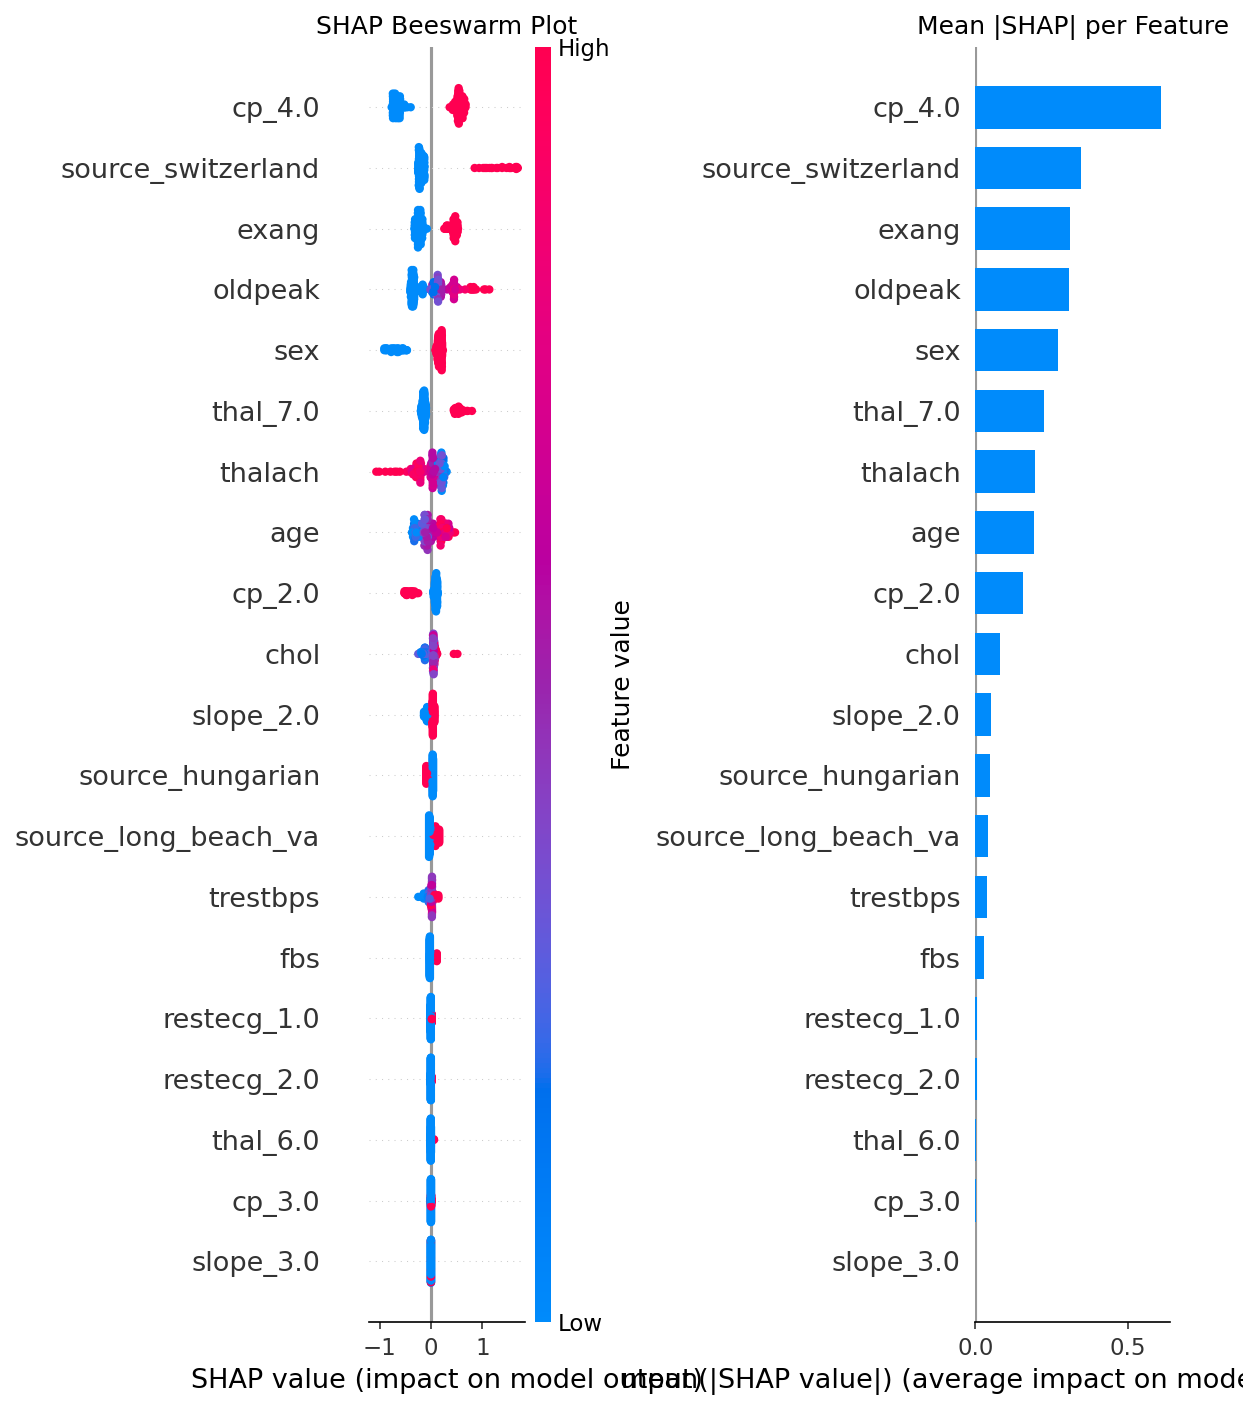

In [10]:
# SHAP Summary plot (beeswarm) and Bar plot
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

plt.sca(axes[0])
shap.summary_plot(shap_values, X_test_transformed, feature_names=feature_names, show=False)
axes[0].set_title("SHAP Beeswarm Plot")

plt.sca(axes[1])
shap.summary_plot(shap_values, X_test_transformed, feature_names=feature_names,
                  plot_type="bar", show=False)
axes[1].set_title("Mean |SHAP| per Feature")

plt.tight_layout()
fig.savefig(f"{FIGURES}/gb_shap_summary.png", dpi=150, bbox_inches="tight")
plt.show()


In [11]:
# Aggregate one-hot SHAP values back to original feature names
# source_hungarian, source_long_beach_va, source_switzerland -> source_code
_MULTICLASS_ORIGINALS = ["cp", "restecg", "thal", "slope"]

original_importance = {}
for col in feature_names:
    original = col
    # Group source_* back to source_code
    if col.startswith("source_"):
        original = "source_code"
    else:
        for name in _MULTICLASS_ORIGINALS:
            if col.startswith(name + "_"):
                original = name
                break
    if original not in original_importance:
        original_importance[original] = 0.0
    original_importance[original] += np.abs(shap_df[col]).mean()

importance_df = (
    pd.DataFrame(list(original_importance.items()), columns=["feature", "mean_abs_shap"])
    .sort_values("mean_abs_shap", ascending=False)
    .reset_index(drop=True)
)
importance_df["rank"] = range(1, len(importance_df) + 1)
importance_df.to_csv(f"{TABLES}/gb_shap_importance.csv", index=False)

print("Feature importance (aggregated to original variables):\n")
importance_df


Feature importance (aggregated to original variables):



,feature,mean_abs_shap,rank
0,cp,0.764861,1
1,source_code,0.435264,2
2,exang,0.309761,3
3,oldpeak,0.306920,4
4,sex,0.269913,5
5,thal,0.228828,6
6,thalach,0.194219,7
7,age,0.190554,8
8,chol,0.080092,9
9,slope,0.050435,10


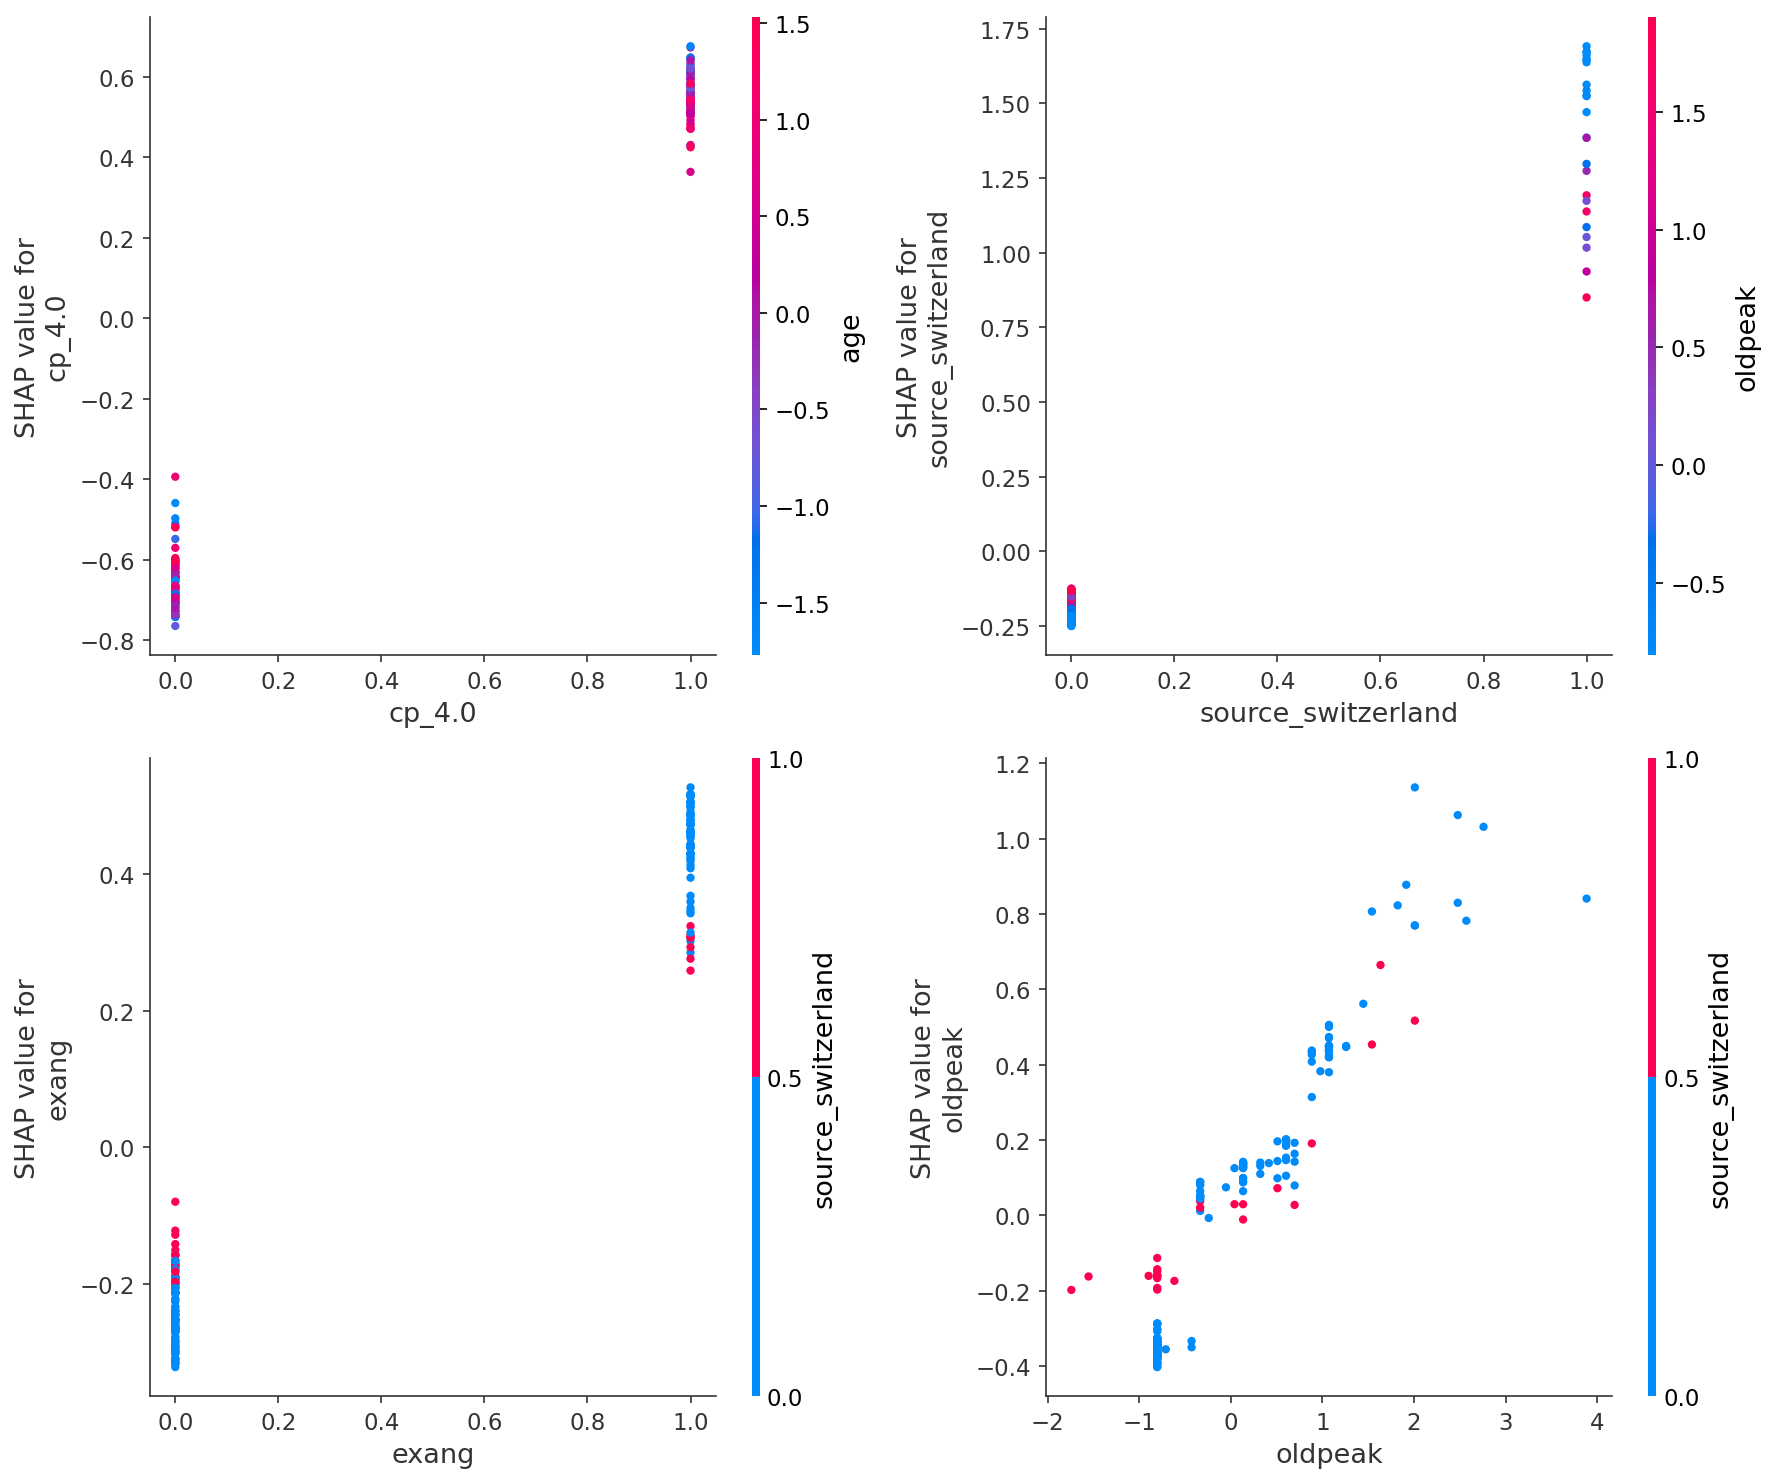

In [12]:
# SHAP Dependence plots for top 4 transformed features
top4_transformed = shap_df.abs().mean().sort_values(ascending=False).head(4).index.tolist()

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
for i, feat in enumerate(top4_transformed):
    ax = axes[i // 2][i % 2]
    feat_idx = feature_names.index(feat)
    shap.dependence_plot(feat_idx, shap_values, X_test_transformed,
                         feature_names=feature_names, ax=ax, show=False)
plt.tight_layout()
fig.savefig(f"{FIGURES}/gb_shap_dependence.png", dpi=150, bbox_inches="tight")
plt.show()


## 6 — Critical Discussion: Why Does `source_code` Rank So High?

The SHAP analysis shows `source_code` as one of the most important predictors. This is a red flag that deserves careful investigation — hospital origin is not a clinical variable and should ideally have no predictive power for heart disease. Several explanations must be considered:

DISEASE PREVALENCE BY SOURCE

Cleveland (n=303):
  No Disease: 164 (54.1%)
  Disease:    139 (45.9%)
  Male:       206 (68.0%)
  Female:     97 (32.0%)
  Mean age:   54.4 years

Hungarian (n=294):
  No Disease: 188 (63.9%)
  Disease:    106 (36.1%)
  Male:       213 (72.4%)
  Female:     81 (27.6%)
  Mean age:   47.8 years

Long Beach VA (n=200):
  No Disease: 51 (25.5%)
  Disease:    149 (74.5%)
  Male:       194 (97.0%)
  Female:     6 (3.0%)
  Mean age:   59.4 years

Switzerland (n=123):
  No Disease: 8 (6.5%)
  Disease:    115 (93.5%)
  Male:       113 (91.9%)
  Female:     10 (8.1%)
  Mean age:   55.3 years


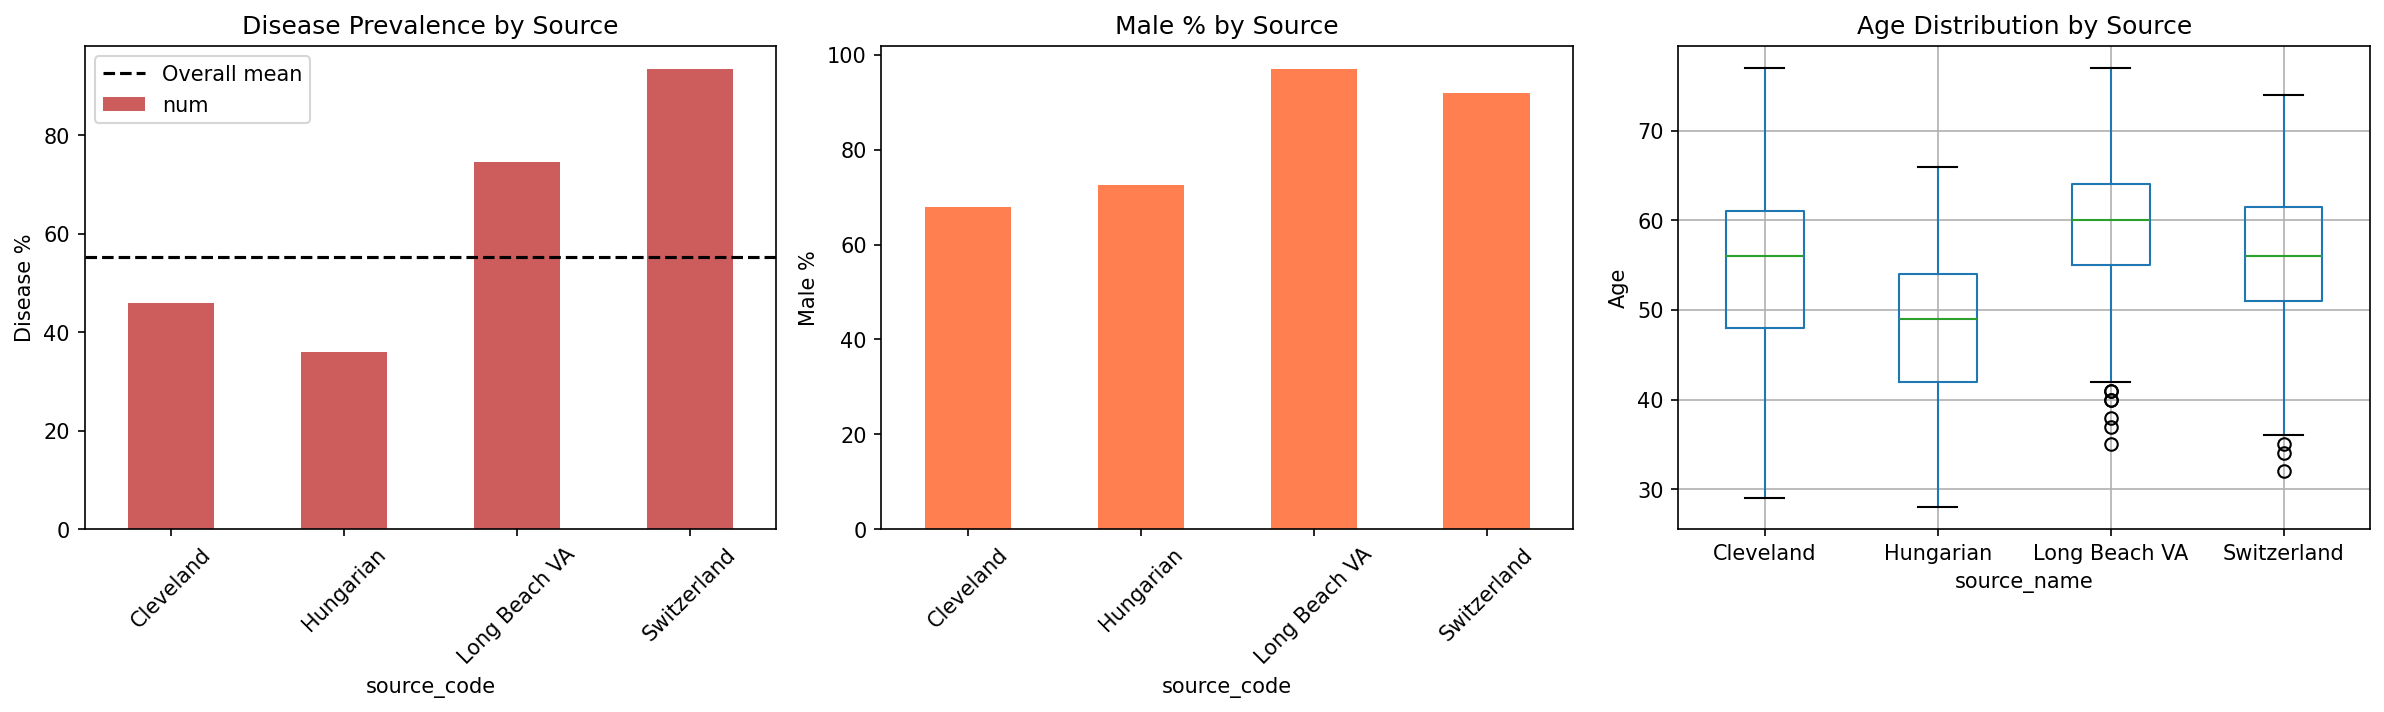

In [13]:
# Detailed analysis: disease prevalence, sex distribution, and age by source
source_map = {1: "Cleveland", 2: "Hungarian", 3: "Long Beach VA", 4: "Switzerland"}

print("=" * 70)
print("DISEASE PREVALENCE BY SOURCE")
print("=" * 70)
for src, name in source_map.items():
    subset = df[df["source_code"] == src]
    n = len(subset)
    n_disease = subset["num"].sum()
    n_healthy = n - n_disease
    print(f"\n{name} (n={n}):")
    print(f"  No Disease: {n_healthy} ({n_healthy/n*100:.1f}%)")
    print(f"  Disease:    {n_disease} ({n_disease/n*100:.1f}%)")
    
    # Sex distribution within source
    n_male = (subset["sex"] == 1).sum()
    n_female = (subset["sex"] == 0).sum()
    print(f"  Male:       {n_male} ({n_male/n*100:.1f}%)")
    print(f"  Female:     {n_female} ({n_female/n*100:.1f}%)")
    
    # Mean age
    print(f"  Mean age:   {subset['age'].mean():.1f} years")

# Summary visualization
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Disease prevalence by source
disease_by_source = df.groupby("source_code")["num"].mean() * 100
disease_by_source.index = disease_by_source.index.map(source_map)
disease_by_source.plot(kind="bar", ax=axes[0], color="indianred")
axes[0].set_title("Disease Prevalence by Source")
axes[0].set_ylabel("Disease %")
axes[0].tick_params(axis="x", rotation=45)
axes[0].axhline(y=df["num"].mean() * 100, color="black", linestyle="--", label="Overall mean")
axes[0].legend()

# Sex distribution by source
sex_by_source = df.groupby("source_code")["sex"].mean() * 100
sex_by_source.index = sex_by_source.index.map(source_map)
sex_by_source.plot(kind="bar", ax=axes[1], color="coral")
axes[1].set_title("Male % by Source")
axes[1].set_ylabel("Male %")
axes[1].tick_params(axis="x", rotation=45)

# Age distribution by source
df_plot = df.copy()
df_plot["source_name"] = df_plot["source_code"].map(source_map)
df_plot.boxplot(column="age", by="source_name", ax=axes[2])
axes[2].set_title("Age Distribution by Source")
axes[2].set_ylabel("Age")
plt.suptitle("")  # Remove automatic title

plt.tight_layout()
fig.savefig(f"{FIGURES}/gb_source_analysis.png", dpi=150, bbox_inches="tight")
plt.show()

### Interpretation: Why `source_code` Has High SHAP Importance

The disease prevalence varies dramatically across sources. This is most likely explained by selection bias rather than genuine geographical differences in heart disease:

1. Referral bias / hospital type: Some datasets may come from specialised cardiology clinics (where patients already have symptoms or high risk) while others may come from general check-ups or population screening. A VA hospital (veterans) serves a population with known cardiovascular risk factors (stress, lifestyle). A university clinic (Cleveland Clinic) may see more referral patients with advanced symptoms. This means `source_code` acts as a proxy for patient acuity, not geography.

2. Different diagnostic thresholds: The four hospitals collected data at different times and may have used slightly different criteria or equipment for diagnosing heart disease. What counts as "disease" (the binarised `num` target) may differ subtly.

3. Different data collection protocols: Some sources may have enrolled consecutive patients, while others may have selected high-risk patients. This creates different base rates by design, not by epidemiology.

4. Cultural and demographic confounders: The populations differ in age distribution, sex ratio, and potentially in ethnicity, diet, and lifestyle — all of which correlate with heart disease risk. The model cannot separate these effects from the source label.

### Gender Imbalance (~75 % Male)

The dataset is heavily skewed toward male patients. This raises several concerns:

- The model has less data to learn female-specific patterns. Heart disease presents differently in women (e.g., atypical chest pain is more common), so the model may be less accurate for female patients. The model does not handle this.
- Potential solutions:
  - Stratified evaluation: Report metrics separately for male and female patients to detect performance gaps
  - Resampling / reweighting: Oversample female patients or assign higher sample weights to them during training
  - Subgroup SHAP analysis: Compute SHAP values separately per sex to check if the model relies on different features for each group
  - Collect more balanced data (ideal but often impractical with historical datasets)

### Other Caution Points

- Temporal differences: The four datasets were collected in different decades. Diagnostic technology, treatment standards, and population health have changed over time. A model trained on 1980s data may not generalise to modern patients.
- Missing data patterns differ by source: `thal` and `slope` had very high missingness in some sources. After imputation, the imputed values may carry source-specific artefacts.
- Leakage risk: If `source_code` is a strong predictor, the model may be "cheating" — learning which hospital has more disease rather than learning clinical patterns. This would hurt generalisation to new, unseen hospitals.

## 7 — Model Persistence

In [14]:
# Save the model and print summary
model_path = f"{MODELS}/gb_best_model.joblib"
joblib.dump(pipe, model_path)

print("=" * 60)
print("GRADIENT BOOSTING — FINAL RESULTS")
print("=" * 60)
print(f"\nVariant:          full_source (13 features)")
print(f"CV ROC-AUC:       {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
print(f"Test ROC-AUC:     {test_auc:.4f}")
print(f"\nHyperparameters:")
for k, v in GBC_PARAMS.items():
    if k != "random_state":
        print(f"  {k:25s} = {v}")
print(f"\nTop-5 features by SHAP importance:")
for _, row in importance_df.head(5).iterrows():
    print(f"  {int(row['rank'])}. {row['feature']:15s}  (mean |SHAP| = {row['mean_abs_shap']:.4f})")

print(f"\nSaved artifacts:")
print(f"  Model:   {model_path}")
print(f"  Tables:  {TABLES}/gb_threshold_comparison.csv")
print(f"           {TABLES}/gb_shap_importance.csv")
print(f"  Figures: {FIGURES}/gb_roc_curve.png")
print(f"           {FIGURES}/gb_confusion_matrix.png")
print(f"           {FIGURES}/gb_shap_summary.png")
print(f"           {FIGURES}/gb_shap_dependence.png")
print(f"           {FIGURES}/gb_source_analysis.png")


GRADIENT BOOSTING — FINAL RESULTS

Variant:          full_source (13 features)
CV ROC-AUC:       0.8903 ± 0.0254
Test ROC-AUC:     0.9176

Hyperparameters:
  n_estimators              = 100
  learning_rate             = 0.05
  max_depth                 = 2
  min_samples_leaf          = 5
  subsample                 = 0.8

Top-5 features by SHAP importance:
  1. cp               (mean |SHAP| = 0.7649)
  2. source_code      (mean |SHAP| = 0.4353)
  3. exang            (mean |SHAP| = 0.3098)
  4. oldpeak          (mean |SHAP| = 0.3069)
  5. sex              (mean |SHAP| = 0.2699)

Saved artifacts:
  Model:   ../results/models/gb_best_model.joblib
  Tables:  ../results/tables/gb_threshold_comparison.csv
           ../results/tables/gb_shap_importance.csv
  Figures: ../results/figures/gb_roc_curve.png
           ../results/figures/gb_confusion_matrix.png
           ../results/figures/gb_shap_summary.png
           ../results/figures/gb_shap_dependence.png
           ../results/figures/gb_so

## 8 — Outlook & Future Steps

This notebook intentionally kept the gradient boosting model simple — fixed hyperparameters, single feature variant, and focus on threshold tuning for medical screening. Several extensions could improve the analysis:

### Model Variants
- Reduced feature sets: Dropping `thal` (53 % originally missing) and `slope` (34 % originally missing) to test whether the model performs equally well without heavily imputed features. Four variants could be compared:
  - `full` (12 features, no `source_code`)
  - `full_source` (13 features, current model)
  - `reduced` (10 features, no `thal`/`slope`/`source_code`)
  - `reduced_source` (11 features, no `thal`/`slope`, with `source_code`)

### Hyperparameter Tuning
- A `GridSearchCV` or `RandomizedSearchCV` over learning rate, tree depth, number of estimators, and regularisation parameters could squeeze additional performance. However, given the small dataset size (920 rows), the risk of overfitting to the validation folds is high.

### Fairness & Robustness
- Stratified evaluation by sex: Report recall, precision, and FN rate separately for male and female patients
- Leave-one-source-out cross-validation: Train on 3 hospitals, test on the 4th. This would reveal whether the model generalises across institutions or merely memorises source-specific patterns.

### Clinical Integration
- Cost-sensitive learning: Assign asymmetric misclassification costs (FN >> FP) directly in the loss function rather than post-hoc threshold tuning
- Ensemble with logistic regression: Use both models and flag disagreements for manual review
- Prospective validation: Test on data from a completely new hospital to assess real-world generalisability